# Recovering an image from absolute values of Fourier coeffients with a U-Net + Attention Model
This notebook trains a PyTorch model to predict a grayscale image from the array of absolute values of its FFT coefficients.

## 1. Imports

In [1]:
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

## 2. Configuration

Modify the paths and hyperparameters here as needed.

In [2]:
IMAGE_DIR = Path("img200x200")
DFT_DIR = Path("abs_dft200x200")

TEST_IMAGE_DIR = Path("img200x200_test")
TEST_DFT_DIR = Path("abs_dft200x200_test")

NUM_SAMPLES = 10000
IMAGE_SIZE = 200
BATCH_SIZE = 32
NUM_EPOCHS = 200
LEARNING_RATE = 2e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Dataset Class

The dataset loads each FFT array and its corresponding grayscale image. FFT coefficients are standardized using global mean and standard deviation computed from the training set.

In [6]:
class DFTImageDataset(Dataset):
    def __init__(self, image_dir, dft_dir, num_samples):
        self.image_dir = image_dir
        self.dft_dir = dft_dir
        self.num_samples = num_samples

        # Estimate normalization statistics for power spectra
        all_dft = []
        for i in range(1, num_samples + 1):
            dft = np.load(dft_dir / f"absdft_{i:05d}.npy")
            all_dft.append(dft)

        all_dft = np.stack(all_dft)
        self.dft_mean = all_dft.mean().astype(np.float32)
        self.dft_std = all_dft.std().astype(np.float32) + 1e-8

        print(f"DFT mean: {self.dft_mean:.6f}")
        print(f"DFT std:  {self.dft_std:.6f}")

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        sample_id = idx + 1

        img_path = self.image_dir / f"image_{sample_id:05d}.jpg"
        dft_path = self.dft_dir / f"absdft_{sample_id:05d}.npy"

        img = Image.open(img_path).convert("L")
        img = np.asarray(img, dtype=np.float32) / 255.0

        dft = np.load(dft_path).astype(np.float32)
        dft = (dft - self.dft_mean) / self.dft_std

        img = torch.from_numpy(img).unsqueeze(0)
        dft = torch.from_numpy(dft).unsqueeze(0)

        return dft, img

## 4. Create Dataset and DataLoader

In [7]:
dataset = DFTImageDataset(IMAGE_DIR, DFT_DIR, NUM_SAMPLES)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Use 0 for notebook compatibility, especially on Windows
)

print(f"Number of training samples: {len(dataset)}")

DFT mean: 2982.593018
DFT std:  28780.986328
Number of training samples: 10000


## 5. Inspect One Training Pair

Power spectrum tensor shape: torch.Size([1, 200, 200])
Image tensor shape: torch.Size([1, 200, 200])


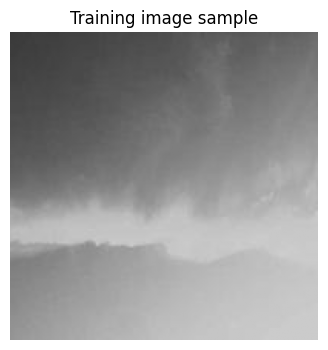

In [8]:
ps_sample, img_sample = dataset[0]

print("Power spectrum tensor shape:", ps_sample.shape)
print("Image tensor shape:", img_sample.shape)

plt.figure(figsize=(4, 4))
plt.imshow(img_sample.squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
plt.title("Training image sample")
plt.axis("off")
plt.show()

## 6. Model Definition

This model uses a U-Net-style architecture with an attention block at the bottleneck. The attention block allows nonlocal/global mixing of information, which is important for learning a transform from DCT coefficients to pixels.

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.LayerNorm(channels)
        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            batch_first=True,
        )

    def forward(self, x):
        # x: [B, C, H, W]
        B, C, H, W = x.shape
        z = x.flatten(2).transpose(1, 2)  # [B, HW, C]
        z_norm = self.norm(z)
        z_attn, _ = self.attn(z_norm, z_norm, z_norm)
        z = z + z_attn
        return z.transpose(1, 2).reshape(B, C, H, W)


class UNetWithAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ConvBlock(1, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            ConvBlock(128, 256),
            AttentionBlock(256, num_heads=4),
            ConvBlock(256, 256),
        )

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = ConvBlock(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)              # 100x100
        e2 = self.enc2(self.pool(e1))  # 50x50
        e3 = self.enc3(self.pool(e2))  # 25x25

        b = self.bottleneck(self.pool(e3))  # 12x12 for 100x100 input

        u3 = self.up3(b)
        u3 = torch.nn.functional.interpolate(u3, size=e3.shape[-2:])
        d3 = self.dec3(torch.cat([u3, e3], dim=1))

        u2 = self.up2(d3)
        u2 = torch.nn.functional.interpolate(u2, size=e2.shape[-2:])
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        u1 = torch.nn.functional.interpolate(u1, size=e1.shape[-2:])
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return torch.sigmoid(self.out(d1))

## 7. Initialize Model, Loss, and Optimizer

In [10]:
model = UNetWithAttention().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")

Trainable parameters: 3,372,705


## 8. Training Loop

In [11]:
loss_history = []

print(f"Training on {DEVICE}")

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for dft, img in loader:
        # Explicitly cast to float to prevent type mismatch with model parameters
        dft = dft.to(DEVICE).float()
        img = img.to(DEVICE).float()

        pred = model(dft)
        loss = criterion(pred, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * dft.size(0)

    avg_loss = total_loss / len(dataset)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch:04d} | Loss: {avg_loss:.8f}")

Training on cuda
Epoch 0001 | Loss: 0.04528095
Epoch 0002 | Loss: 0.04022466
Epoch 0003 | Loss: 0.03920774
Epoch 0004 | Loss: 0.03835492
Epoch 0005 | Loss: 0.03734071
Epoch 0006 | Loss: 0.03586232
Epoch 0007 | Loss: 0.03434481
Epoch 0008 | Loss: 0.03260630
Epoch 0009 | Loss: 0.03034087
Epoch 0010 | Loss: 0.02737757
Epoch 0011 | Loss: 0.02474270
Epoch 0012 | Loss: 0.02174333
Epoch 0013 | Loss: 0.01950892
Epoch 0014 | Loss: 0.01817206
Epoch 0015 | Loss: 0.01588580
Epoch 0016 | Loss: 0.01400831
Epoch 0017 | Loss: 0.01378769
Epoch 0018 | Loss: 0.01174361
Epoch 0019 | Loss: 0.01104608
Epoch 0020 | Loss: 0.01029129
Epoch 0021 | Loss: 0.00973153
Epoch 0022 | Loss: 0.00917075
Epoch 0023 | Loss: 0.00870963
Epoch 0024 | Loss: 0.00826613
Epoch 0025 | Loss: 0.00792725
Epoch 0026 | Loss: 0.00765653
Epoch 0027 | Loss: 0.00726086
Epoch 0028 | Loss: 0.00704884
Epoch 0029 | Loss: 0.00679311
Epoch 0030 | Loss: 0.00652009
Epoch 0031 | Loss: 0.00630084
Epoch 0032 | Loss: 0.00619377
Epoch 0033 | Loss: 0.00

## 9. Plot Training Loss

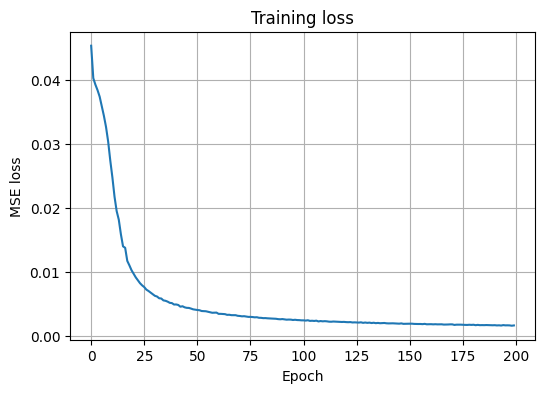

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.grid(True)
plt.show()

## 10. Predict the Test Image

In [13]:
model.eval()

for i in range(10001, 10101):
    test_dft = np.load(TEST_DFT_DIR / f"absdft_{i:05d}.npy").astype(np.float32)
    test_dft = (test_dft - dataset.dft_mean) / dataset.dft_std

    test_dft = torch.from_numpy(test_dft).unsqueeze(0).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(test_dft)

    pred_img = pred.squeeze().cpu().numpy()
    pred_img_uint8 = np.clip(pred_img * 255.0, 0, 255).astype(np.uint8)

    Image.fromarray(pred_img_uint8, mode="L").save(TEST_IMAGE_DIR/ f"image_{i:05d}_dft_pred.jpg")

print(f"Saved predicted image to {TEST_IMAGE_DIR.resolve()}")

Saved predicted image to C:\Users\space\Documents\Git\blind-DCT\img200x200_test


## 11. Display Predicted Image

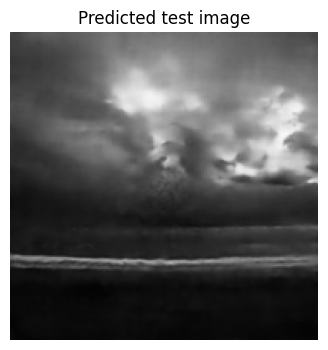

In [14]:
plt.figure(figsize=(4, 4))
plt.imshow(pred_img_uint8, cmap="gray", vmin=0, vmax=255)
plt.title("Predicted test image")
plt.axis("off")
plt.show()

## 12. Save the Trained Model

In [ ]:
checkpoint_path = Path("unet_attention_absdft_to_image.pt")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "dft_mean": dataset.dft_mean,
        "dft_std": dataset.dft_std,
        "loss_history": loss_history,
        "config": {
            "num_samples": NUM_SAMPLES,
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,
            "num_epochs": NUM_EPOCHS,
            "learning_rate": LEARNING_RATE,
        },
    },
    checkpoint_path,
)

print(f"Saved checkpoint to {checkpoint_path.resolve()}")

AttributeError: 'DFTImageDataset' object has no attribute 'ps_mean'